# Multiple Linear Regression

## 0. All Imports

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns

## 1. Understand the problem statement

Not given

## 2. Data Collection

In [4]:
# Step 3: Column names from original Boston dataset
feature_names = [
    "CRIM",  # per capita crime rate by town
    "ZN",  # proportion of residential land zoned for lots over 25,000 sq.ft.
    "INDUS",  # proportion of non-retail business acres per town
    "CHAS",  # Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
    "NOX",  # nitric oxides concentration (parts per 10 million)
    "RM",  # average number of rooms per dwelling
    "AGE",  # proportion of owner-occupied units built prior to 1940
    "DIS",  # weighted distances to five Boston employment centres
    "RAD",  # index of accessibility to radial highways
    "TAX",  # full-value property-tax rate per $10,000
    "PTRATIO",  # pupil-teacher ratio by town
    "B",  # 1000(Bk - 0.63)^2 where Bk is the proportion of Black people
    "LSTAT",  # % lower status of the population
]

In [5]:
df = pd.read_csv("bostonhousePrice.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


## 3. Data Cleaning and finding outliers

In [6]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [7]:
# sns.pairplot(df)

In [8]:
df.rename(columns={"MEDV": "Price"}, inplace=True)

In [9]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'Price'],
      dtype='object')

<Axes: xlabel='TAX', ylabel='Price'>

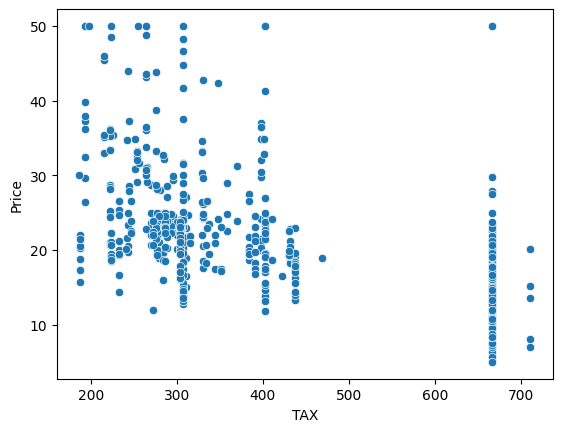

In [10]:
sns.scatterplot(x=df["TAX"], y=df["Price"])

<Axes: >

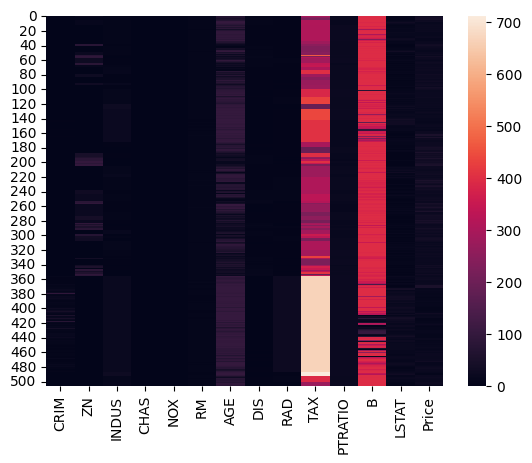

In [11]:
sns.heatmap(df)

<Axes: >

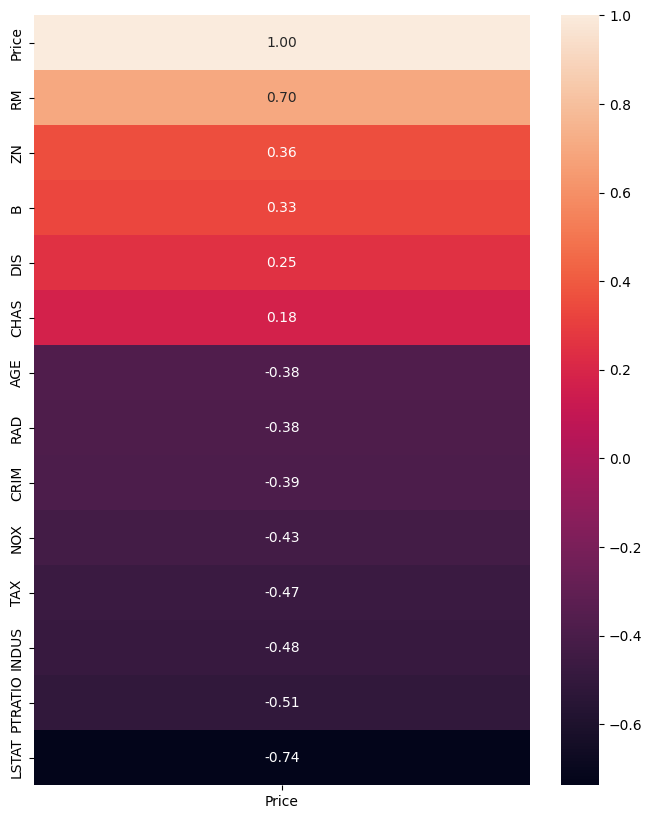

In [12]:
corr = df.corr()[["Price"]].sort_values(by="Price", ascending=False)

# plot
plt.figure(figsize=(8, 10))
sns.heatmap(corr, annot=True, fmt=".2f")

In [13]:
# independent/
x = df.iloc[:, :-1]
x.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [14]:
# dependent
y = df.iloc[:, -1]
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: Price, dtype: float64

## 4. Importing model from scikit-learn

Work flow: <br>
1. Train
2. Test
3. Split
4. Training Model

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.30, random_state=20
)

In [17]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((354, 13), (152, 13), (354,), (152,))

# 5.Data Transformation

In [18]:
# data transformation
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
x_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
388,14.33370,0.0,18.10,0.0,0.700,4.880,100.0,1.5895,24.0,666.0,20.2,372.92,30.62
424,8.79212,0.0,18.10,0.0,0.584,5.565,70.6,2.0635,24.0,666.0,20.2,3.65,17.16
45,0.17142,0.0,6.91,0.0,0.448,5.682,33.8,5.1004,3.0,233.0,17.9,396.90,10.21
470,4.34879,0.0,18.10,0.0,0.580,6.167,84.0,3.0334,24.0,666.0,20.2,396.90,16.29
28,0.77299,0.0,8.14,0.0,0.538,6.495,94.4,4.4547,4.0,307.0,21.0,387.94,12.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,18.81100,0.0,18.10,0.0,0.597,4.628,100.0,1.5539,24.0,666.0,20.2,28.79,34.37
223,0.61470,0.0,6.20,0.0,0.507,6.618,80.8,3.2721,8.0,307.0,17.4,396.90,7.60
271,0.16211,20.0,6.96,0.0,0.464,6.240,16.3,4.4290,3.0,223.0,18.6,396.90,6.59
474,8.05579,0.0,18.10,0.0,0.584,5.427,95.4,2.4298,24.0,666.0,20.2,352.58,18.14


In [21]:
x_train=scaler.fit_transform(x_train)

In [22]:
x_train

array([[ 1.43381743, -0.51141863,  0.97447189, ...,  0.84927271,
         0.18135956,  2.44467971],
       [ 0.7058239 , -0.51141863,  0.97447189, ...,  0.84927271,
        -3.9338946 ,  0.61699264],
       [-0.4266715 , -0.51141863, -0.62133803, ..., -0.21881169,
         0.44859978, -0.32672394],
       ...,
       [-0.42789455,  0.34833298, -0.61420751, ...,  0.10625747,
         0.44859978, -0.81827128],
       [ 0.60909273, -0.51141863,  0.97447189, ...,  0.84927271,
        -0.04531541,  0.75006347],
       [-0.43518817,  2.92758778, -1.33438982, ...,  1.68516484,
         0.21612977, -0.95677357]])

In [23]:
x_train.shape

(354, 13)

## 6. Model training

### Imported Linear Regression model

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
model = LinearRegression()

In [26]:
print(dir(model))

['__abstractmethods__', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_build_request_for_signature', '_check_feature_names', '_check_n_features', '_decision_function', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_get_default_requests', '_get_doc_link', '_get_metadata_request', '_get_param_names', '_get_tags', '_more_tags', '_parameter_constraints', '_repr_html_', '_repr_html_inner', '_repr_mimebundle_', '_set_intercept', '_validate_data', '_validate_params', 'copy_X', 'fit', 'fit_intercept', 'get_metadata_routing', 'get_params', 'n_jobs', 'positive', 'predict

In [27]:
model.fit(x_train, y_train)

LinearRegression()

# 7.Accuracy Calculation

In [28]:
#train accuracy
model.score(x_train,y_train)

0.7476893972682184

In [29]:
y_test_pred= model.predict(x_test)

C:\Users\vishal sengwa\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [30]:
y_test_pred

array([ -344.68514902,  -111.72659496,  -370.49620329,  -218.62453314,
       -1140.73188106,  -200.88001212,  -182.94572336,  -845.4874955 ,
        -221.82096712,  -209.27783301,    -1.28183061,  -375.69165932,
        -164.88667451,  -216.82305802,   -67.52278628,  -163.26754811,
        -115.47506016,  -804.62143106,  -438.12703628,  -224.15762535,
        -159.74208348,    23.85727249,  -135.374473  ,  -222.57256412,
        -153.94296661,  -179.34608933,  -214.35738221,  -157.67431508,
        -204.42586027,  -177.54285043,  -975.71927268,  -843.57239994,
         -17.03447847, -1138.91880476,  -169.67937645,  -598.20911394,
         -70.72779221,   -63.79147824,   -69.09109373,   -73.87934956,
        -838.74107788,  -810.418433  ,  -821.36683876,  -620.52218272,
        -151.86290995,  -131.97011943,   -61.00245287,  -212.35368689,
        -819.3751053 , -1130.66806902,  -191.4607525 ,  -183.02874217,
        -942.7887077 ,   -26.1995386 ,  -225.2966817 ,  -767.40024218,
      

In [31]:
y_test

498    21.2
94     20.6
150    21.5
221    21.7
423    13.4
       ... 
104    20.1
418     8.8
110    21.7
309    20.3
390    15.1
Name: Price, Length: 152, dtype: float64

In [32]:
from sklearn.metrics import r2_score

In [33]:
r2_score(y_test_pred,y_test)

-1.531174238159204

In [34]:
import numpy as np
data=np.array([[0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98]])

In [35]:
t_data=scaler.transform(data)

C:\Users\vishal sengwa\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [36]:
model.predict(t_data)

array([29.60681995])

In [37]:
import joblib

In [38]:
joblib.dump(model, "model.joblib")

['model.joblib']

In [39]:
joblib.dump(model, "scaler.joblib")

['scaler.joblib']

# Regularation

## Overfitting
Train data => High acc<br>
test data => low acc

## Underfitting
Train data => low acc<br>
test data => low acc

## Elastic Net
L1 + L2

In [40]:
from sklearn.linear_model import Ridge

In [41]:
ridge=Ridge()

In [42]:
x_train.shape,y_train.shape

((354, 13), (354,))

In [43]:
ridge.fit(x_train,y_train)

Ridge()

In [45]:
#train acc
x_train_pred = ridge.predict(x_train)
r2_score(x_train_pred,y_train)

0.6611137020697726

In [63]:
#test acc
x_test_pred = ridge.predict(x_test)
r2_score(x_test_pred,y_test)

C:\Users\vishal sengwa\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


-1.4426604519374289

# Lasso


In [48]:
from sklearn.linear_model import Lasso

In [50]:
lasso=Lasso()

In [51]:
x_train.shape,y_train.shape

((354, 13), (354,))

In [52]:
lasso.fit(x_train,y_train)

Lasso()

In [53]:
#train acc
x_train_pred = lasso.predict(x_train)
r2_score(x_train_pred,y_train)

0.3660718604857519

In [54]:
#test acc
x_test_pred = lasso.predict(x_test)
r2_score(x_test_pred,y_test)

C:\Users\vishal sengwa\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


0.09445598195470695

In [49]:
from sklearn.linear_model import ElasticNet

In [55]:
elastic=ElasticNet()

In [56]:
x_train.shape,y_train.shape

((354, 13), (354,))

In [57]:
elastic.fit(x_train,y_train)

ElasticNet()

In [58]:
#train acc
x_train_pred = elastic.predict(x_train)
r2_score(x_train_pred,y_train)

0.1726901174726001

In [59]:
#test acc
x_test_pred = elastic.predict(x_test)
r2_score(x_test_pred,y_test)

C:\Users\vishal sengwa\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but ElasticNet was fitted without feature names
  warnings.warn(


-0.1081490452392504